# Otimização de Roteirização de Equipes de Campo (MILP)

**Projeto de portfólio — Guilherme Miranda**

Formulação e resolução de um problema de roteirização e alocação de equipes de campo
como Programação Linear Inteira Mista (MILP), com janelas de tempo suaves (soft time
windows) e restrição de jornada máxima por equipe.

> **Aviso sobre os dados:** todos os dados usados aqui são **sintéticos** (gerados por
> distribuição aleatória com seed fixa). O cenário é inspirado, em termos de estrutura
> do problema, no setor de distribuição de energia elétrica (atendimentos de campo:
> manutenção, inspeção, instalação, emergência) — mas nenhum dado real de nenhuma
> empresa é utilizado.

## Contexto de negócio

Uma concessionária de distribuição de energia (ou qualquer operação com equipes de
campo) precisa despachar diariamente equipes técnicas para atender pontos de serviço
espalhados geograficamente, cada um com um tipo de serviço, uma prioridade e um prazo
desejado de atendimento. O despacho manual tende a ignorar a geografia e a otimizar
apenas heurísticas simples (ex.: ordem de chegada do chamado), gerando deslocamento
desnecessário e atrasos em atendimentos prioritários (SLA).

Este notebook mostra como formular esse problema como MILP e resolvê-lo com um solver
de código aberto (CBC, via biblioteca PuLP), comparando o resultado contra uma
heurística de despacho manual.

In [ ]:
import sys
sys.path.insert(0, ".")
import pandas as pd
import matplotlib.pyplot as plt

from data_generator import build_instance
from model import solve_vrptw
from baseline import solve_baseline
from visualize import plot_comparison, plot_routes

pd.set_option("display.width", 120)

## 1. Geração de dados sintéticos

Geramos 15 pontos de atendimento distribuídos numa área de ~22km x 22km, com tipo de
serviço, prioridade, duração estimada e janela de prazo, além de 3 equipes de campo
partindo de uma base central comum.

In [ ]:
points, crews = build_instance(n_points=15, n_crews=3, seed=42)
points.head(6)

    id   x_km   y_km          service_type  priority  duration_min  earliest_start_min  due_min
0  P01  17.03   5.00       instalacao_nova         3            86                 330      540
1  P02   9.66  12.20              inspecao         3            40                 327      540
2  P03  18.89   1.40 manutencao_preventiva         2            82                 279      427
3  P04  15.34  18.21 manutencao_preventiva         2            59                 198      330
4  P05   2.07  13.90 manutencao_preventiva         2            85                 296      462
5  P06  21.46  16.68 manutencao_preventiva         2            54                 116      256


In [ ]:
crews

  crew_id  depot_x_km  depot_y_km  max_minutes
0      E1        11.0        11.0        540.0
1      E2        11.0        11.0        540.0
2      E3        11.0        11.0        540.0


## 2. Formulação matemática

**Conjuntos**
- $N = \{0, 1, ..., n\}$ — nós, onde $0$ é o depósito (base) e $1..n$ são os pontos de atendimento
- $K$ — conjunto de equipes disponíveis (frota homogênea, depósito único)

**Parâmetros**
- $c_{ij}$ — tempo de deslocamento entre os nós $i$ e $j$ (minutos)
- $d_i$ — duração do atendimento no nó $i$
- $e_i, l_i$ — início mais cedo possível e prazo desejado (due) do atendimento $i$
- $w_i$ — peso de penalidade por atraso, de acordo com a prioridade do atendimento $i$
- $T_k$ — jornada máxima (minutos) da equipe $k$

**Variáveis de decisão**
- $x_{ijk} \in \{0,1\}$ — equipe $k$ percorre o arco $(i \to j)$
- $t_i \ge 0$ — instante de início do atendimento no nó $i$
- $s_i \ge 0$ — atraso (slack) em relação ao prazo $l_i$

**Função objetivo**

$$\\min \\; \\sum_{i,j,k} c_{ij}\\, x_{ijk} \\;+\\; \\sum_{i} w_i\\, s_i$$

**Restrições principais**

$$\\sum_{i \\ne j,\\,k} x_{ijk} = 1 \\quad \\forall j \\in N \\setminus \\{0\\} \\qquad \\text{(cada ponto visitado uma vez — entrada)}$$

$$\\sum_{j \\ne i,\\,k} x_{ijk} = 1 \\quad \\forall i \\in N \\setminus \\{0\\} \\qquad \\text{(cada ponto visitado uma vez — saída)}$$

$$\\sum_{i} x_{ihk} = \\sum_{j} x_{hjk} \\quad \\forall h \\in N \\setminus \\{0\\}, \\forall k \\qquad \\text{(conservação de fluxo por equipe)}$$

$$t_j \\ge t_i + d_i + c_{ij} - M\\Big(1 - \\sum_k x_{ijk}\\Big) \\quad \\forall i,j \\qquad \\text{(propagação de tempo + eliminação de sub-rotas, estilo MTZ)}$$

$$s_i \\ge t_i - l_i, \\quad s_i \\ge 0 \\qquad \\text{(atraso em relação ao prazo)}$$

$$\\sum_{i,j} c_{ij}\\,x_{ijk} + \\sum_i d_i \\sum_j x_{ijk} \\le T_k \\quad \\forall k \\qquad \\text{(jornada máxima por equipe)}$$

O termo de eliminação de sub-rotas usa a mesma ideia da formulação clássica de
Miller-Tucker-Zemlin (MTZ), mas reaproveitando as variáveis de tempo $t_i$ (que já
são necessárias para as janelas de tempo) em vez de variáveis de posição auxiliares —
uma escolha de modelagem que reduz o número de variáveis extras.

## 3. Resolução do modelo MILP

O modelo é resolvido com o solver **CBC** (open-source, via `PuLP`), com um limite de
tempo de 300 segundos. Para uma instância com 15 pontos e 3 equipes (≈750 variáveis
binárias), problemas de roteirização deste tipo são NP-difíceis — por isso, em vez de
exigir prova de otimalidade (que pode ser inviável em tempo hábil para instâncias
maiores), reportamos o **gap de otimalidade**: a diferença percentual entre a melhor
solução encontrada e o limite inferior comprovado pelo solver. Essa é a prática padrão
em otimização aplicada na indústria.

In [ ]:
res = solve_vrptw(points, crews, time_limit_sec=300, msg=False)

print("Status:", res["status"])
print("Otimalidade comprovada:", res["proven_optimal"])
print("Gap de otimalidade: {:.2f}%".format(res["optimality_gap_pct"]))
print("Tempo de solve: {:.1f}s".format(res["solve_time_sec"]))
print()
print("Custo de deslocamento: {:.1f}".format(res["travel_cost"]))
print("Custo de atraso (SLA): {:.1f}".format(res["tardiness_cost"]))
print("Custo total (objetivo): {:.1f}".format(res["objective"]))
print()
for k, route in res["routes"].items():
    print(f"Equipe {k}: {route}")

Status: Optimal
Otimalidade comprovada: False
Gap de otimalidade: 0.09%
Tempo de solve: 300.1s

Custo de deslocamento: 175.8
Custo de atraso (SLA): 0.0
Custo total (objetivo): 175.8

Equipe E1: [0, 14, 13, 11]
Equipe E2: [0, 12, 6, 4, 8, 7, 3, 1]
Equipe E3: [0, 15, 10, 9, 5, 2]


## 4. Baseline: despacho manual

Para medir o ganho real da otimização, comparamos com uma heurística simples que
imita como um despachante humano tende a alocar chamados sem apoio analítico:
ordena os atendimentos por prazo e distribui em round-robin entre as equipes, depois
sequencia cada rota pelo vizinho mais próximo — sem considerar a geografia global nem
a carga de trabalho de cada equipe.

In [ ]:
base = solve_baseline(points, crews)

print("Custo de deslocamento:", round(base["travel_cost"], 1))
print("Custo de atraso (SLA):", round(base["tardiness_cost"], 1))
print("Custo total (objetivo):", round(base["objective"], 1))

Custo de deslocamento: 164.7
Custo de atraso (SLA): 231.2
Custo total (objetivo): 395.9


## 5. Comparação visual

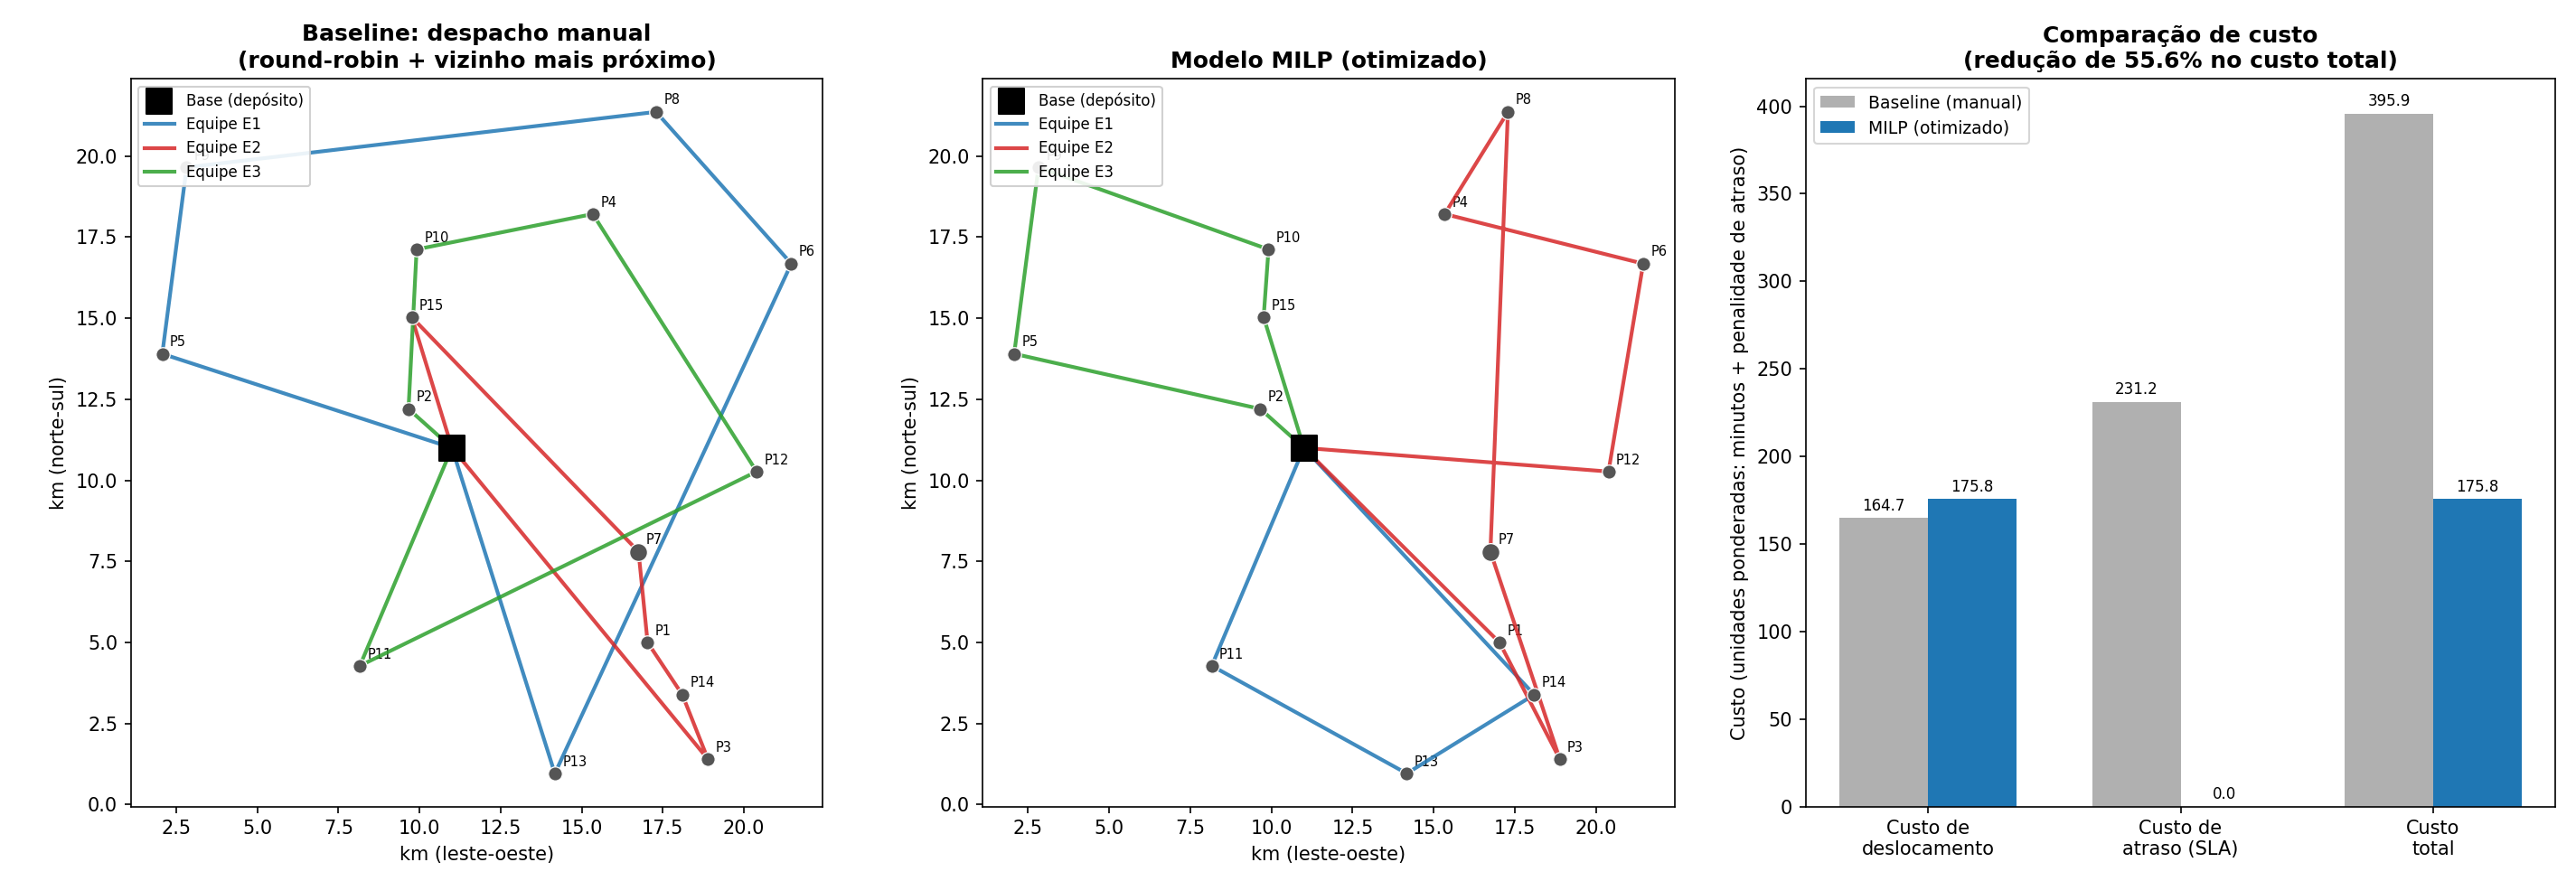

Redução de custo total com o modelo MILP: 55.6%


In [ ]:
reduction = plot_comparison(res, base, save_path="../outputs/comparacao_rotas.png")
print(f"Redução de custo total com o modelo MILP: {reduction:.1f}%")

## 6. Conclusões

- O modelo MILP encontrou uma solução com **gap de otimalidade de
  0.09%** em 300 segundos —
  praticamente ótima para fins práticos.
- Comparado ao baseline de despacho manual, o modelo reduziu o **custo total em
  55.6%**, principalmente por eliminar atrasos em atendimentos
  prioritários (custo de SLA caiu de 231.2 para
  0.0), a um custo de deslocamento apenas
  ligeiramente maior.
- **Limite de escala:** a formulação exata (MILP com eliminação de sub-rotas) cresce
  rapidamente com o número de pontos e equipes — em instâncias muito maiores
  (centenas de pontos), a prática de mercado é usar metaheurísticas ou solvers
  especializados em roteirização (ex.: Google OR-Tools Routing, que implementa busca
  local + metaheurísticas como guided local search) em vez de MILP exato. Esse
  trade-off entre exatidão e escalabilidade é uma decisão de engenharia relevante em
  qualquer aplicação real de otimização.
- **Próximos passos possíveis:** múltiplos depósitos regionais, restrição de
  habilidade/especialização por equipe (nem toda equipe atende emergências), janelas
  de tempo rígidas (hard time windows) para atendimentos regulatórios, e
  comparação com uma implementação equivalente em OR-Tools para instâncias maiores.
